In [1]:
!nvidia-smi

Fri Sep 18 19:17:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

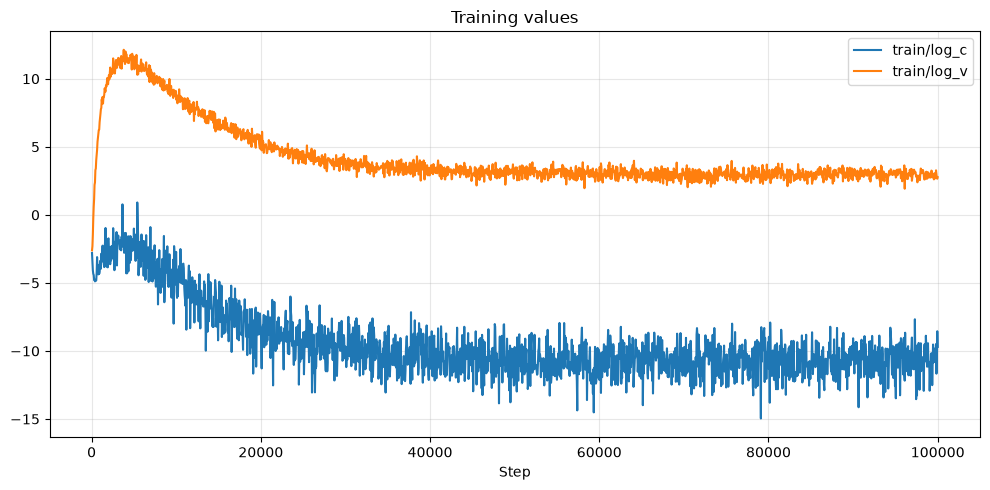

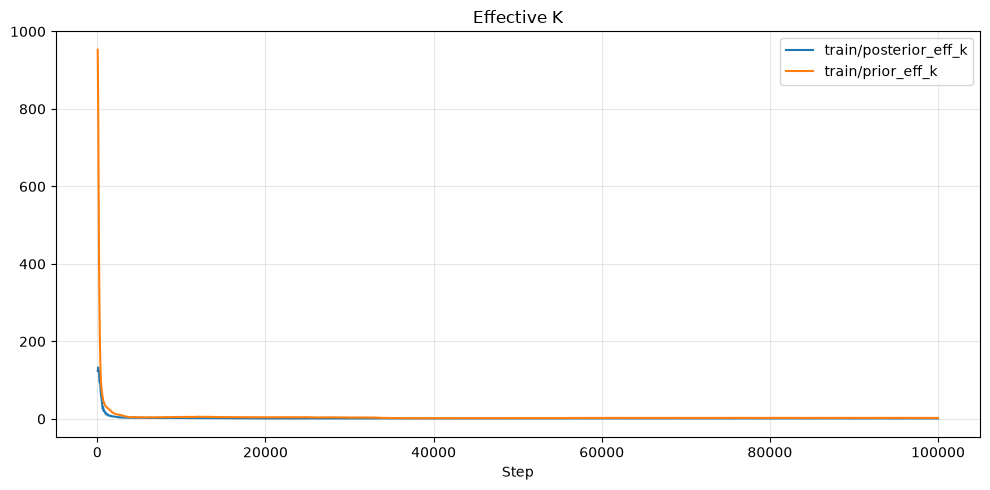

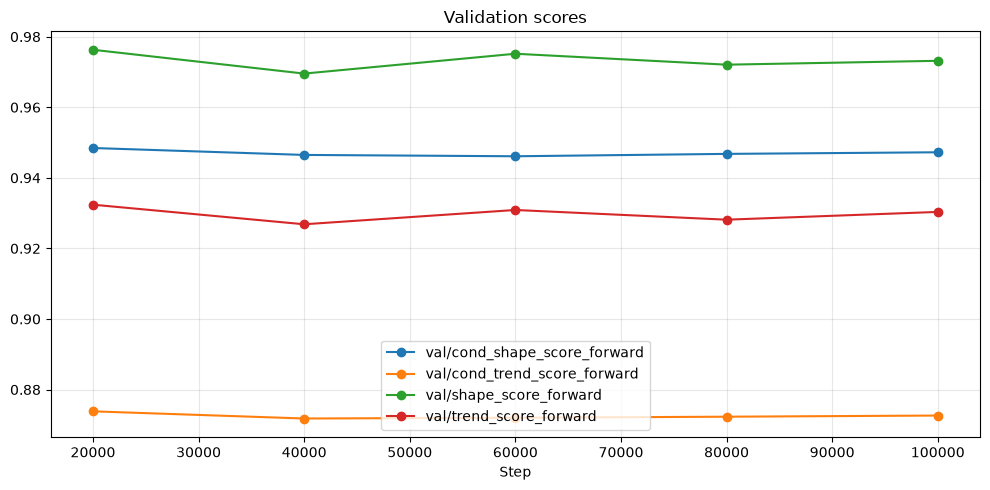

Финальные test-метрики:


,0
test/cond_shape_score_forward,0.946497
test/cond_trend_score_forward,0.871930
test/iteration,6.000000
test/log_c,-10.828632
test/log_v,2.931638
test/posterior_eff_k,1.211370
test/prior_eff_k,2.615547
test/shape_score_forward,0.972875
test/trend_score_forward,0.933050


In [2]:
import pandas as pd
import matplotlib.pyplot as plt


path = (
    "logs/runs/dlight_sb/benchmark_hd/d2_g002/42/"
    "2026-09-18_22-02-45/metrics"
)

train = pd.read_csv(f"{path}/train/metrics.csv")
test = pd.read_csv(f"{path}/test/metrics.csv")


groups = {
    "Training values": [
        "train/log_c",
        "train/log_v",
    ],
    "Effective K": [
        "train/posterior_eff_k",
        "train/prior_eff_k",
    ],
    "Validation scores": [
        "val/cond_shape_score_forward",
        "val/cond_trend_score_forward",
        "val/shape_score_forward",
        "val/trend_score_forward",
    ],
}


for title, columns in groups.items():
    available = [
        column
        for column in columns
        if column in train.columns
    ]

    if not available:
        print(f"{title}: нужные столбцы отсутствуют")
        continue

    # Удаляем строки, в которых отсутствуют все метрики группы.
    # Для validation это оставит пять последовательных точек —
    # по одной на каждую эпоху.
    plot_data = train[["step", *available]].dropna(
        subset=available,
        how="all",
    )

    if plot_data.empty:
        print(f"{title}: нет непустых значений")
        continue

    ax = plot_data.plot(
        x="step",
        y=available,
        figsize=(10, 5),
        marker="o" if title == "Validation scores" else None,
        linewidth=1.5,
        title=title,
    )

    ax.set_xlabel("Step")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


print("Финальные test-метрики:")

test_metrics = (
    test
    .drop(columns=["epoch", "step"], errors="ignore")
    .dropna(axis=1, how="all")
    .T
)

display(test_metrics)